# 🎬 Netflix Movies & TV Shows — End-to-End Data Science Project

**Author:** Senior Data Scientist Portfolio Project
**Dataset:** Netflix Titles (Movies & TV Shows metadata)

## 1. Business Problem

Netflix operates the world's largest subscription streaming catalogue, spanning
thousands of licensed and original Movies and TV Shows across genres, countries,
and audience-maturity tiers. Understanding the **composition, evolution, and
gaps** in this catalogue is critical to:

- **Content Strategy** — deciding where to invest in acquisition/production (genres, countries, formats)
- **Subscriber Retention** — aligning content mix with audience demand (family vs. adult content, movies vs. series)
- **Regional Expansion** — identifying under-served markets and genres
- **Personalization** — powering recommendation systems that keep subscribers engaged

This project performs a full data science workflow — **cleaning → EDA → feature
engineering → a content-based recommendation engine → business insights** — culminating
in an interactive Netflix-themed dashboard.

---


## 2. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from difflib import get_close_matches
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

print("Libraries loaded successfully.")


Libraries loaded successfully.


---
## 3. Data Loading & Initial Inspection


In [2]:
df_raw = pd.read_csv("data/netflix_titles.csv")
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()


Shape: 8,807 rows x 12 columns


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         88

In [4]:
print("Missing values per column:\n")
print(df_raw.isna().sum().sort_values(ascending=False))


Missing values per column:

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64


**Observation:** `director`, `cast`, and `country` have substantial missing
values, `date_added` and `rating`/`duration` have a handful of missing rows.
Data types for `date_added` (string) and `duration` (mixed units) need fixing.

---
## 4. Data Cleaning

We apply, in order: duplicate removal → text standardisation → missing-value
handling → dtype fixes → inconsistent-value fixes.


In [5]:
def drop_duplicates(df):
    before = len(df)
    df = df.drop_duplicates(subset=["title", "type", "director", "country"], keep="first")
    df = df.drop_duplicates(subset=["show_id"], keep="first")
    print(f"Duplicates removed: {before - len(df):,} rows")
    return df

def standardize_text_columns(df):
    text_cols = ["type", "title", "director", "cast", "country", "rating", "listed_in", "description"]
    for col in text_cols:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"nan": np.nan, "": np.nan, "None": np.nan})
    df["country"] = df["country"].str.replace(r"\s*,\s*", ", ", regex=True)
    df["director"] = df["director"].str.replace(r"\s*,\s*", ", ", regex=True)
    df["cast"] = df["cast"].str.replace(r"\s*,\s*", ", ", regex=True)
    df["listed_in"] = df["listed_in"].str.replace(r"\s*,\s*", ", ", regex=True)
    rating_fix = {"UR": "NR", "TV-Y7-FV": "TV-Y7"}
    df["rating"] = df["rating"].replace(rating_fix)
    return df

def handle_missing_values(df):
    df["director"] = df["director"].fillna("Not Specified")
    df["cast"] = df["cast"].fillna("Not Specified")
    df["country"] = df["country"].fillna("Not Specified")

    for content_type in df["type"].unique():
        type_mode = df.loc[df["type"] == content_type, "rating"].mode()
        if len(type_mode):
            df.loc[(df["type"] == content_type) & (df["rating"].isna()), "rating"] = type_mode[0]

    before = len(df)
    df = df.dropna(subset=["date_added"])
    print(f"Rows dropped due to missing 'date_added': {before - len(df):,}")

    for content_type in df["type"].unique():
        type_mode = df.loc[df["type"] == content_type, "duration"].mode()
        if len(type_mode):
            df.loc[(df["type"] == content_type) & (df["duration"].isna()), "duration"] = type_mode[0]
    return df

def fix_dtypes(df):
    df["date_added"] = pd.to_datetime(df["date_added"].str.strip(), format="%B %d, %Y", errors="coerce")
    df["release_year"] = df["release_year"].astype(int)
    df["duration_value"] = df["duration"].str.extract(r"(\d+)").astype(float)
    df["duration_unit"] = df["duration"].apply(
        lambda x: "Season(s)" if "Season" in str(x) else ("min" if "min" in str(x) else np.nan)
    )
    return df

def fix_inconsistent_values(df):
    df["primary_country"] = df["country"].apply(lambda x: x.split(",")[0].strip())
    df = df[df["type"].isin(["Movie", "TV Show"])]
    return df

df = df_raw.copy()
df = drop_duplicates(df)
df = standardize_text_columns(df)
df = handle_missing_values(df)
df = fix_dtypes(df)
df = fix_inconsistent_values(df)
df = df.reset_index(drop=True)

print(f"\nFinal cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Remaining nulls: {df.isna().sum().sum()}")


Duplicates removed: 0 rows
Rows dropped due to missing 'date_added': 10

Final cleaned dataset: 8,797 rows x 15 columns
Remaining nulls: 0


In [6]:
df.to_csv("cleaned_netflix_dataset.csv", index=False)
print("Saved -> cleaned_netflix_dataset.csv")
df.head()


Saved -> cleaned_netflix_dataset.csv


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water    Not Specified   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans    Not Specified   
4      s5  TV Show           Kota Factory    Not Specified   

                                                cast        country  \
0                                      Not Specified  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...  Not Specified   
3                                      Not Specified  Not Specified   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

  date_added  release_year rating   duration  \
0 2021-09-25          2020  PG-13     90 min   
1 2021-09-24          2021  TV-MA  2 Seasons   
2 2021-09-24          2021  TV-MA   1 Season   
3 2021-0

**Business takeaway:** Only 10 rows (0.1%) were dropped (missing `date_added`,
which cannot be safely imputed for a time-series "content added" analysis).
Categorical gaps in `director`/`cast`/`country` were preserved as an explicit
`"Not Specified"` label rather than silently dropped, since ~30% of TV Shows
legitimately lack a credited director in this dataset (ensemble/anthology
productions) — dropping them would materially bias genre and country analysis.

---
## 5. Feature Engineering


In [7]:
def add_date_features(df):
    df["date_added"] = pd.to_datetime(df["date_added"])
    df["year_added"] = df["date_added"].dt.year
    df["month_added"] = df["date_added"].dt.month
    df["month_name_added"] = df["date_added"].dt.month_name()
    df["weekday_added"] = df["date_added"].dt.day_name()
    df["years_to_add"] = (df["year_added"] - df["release_year"]).clip(lower=0)
    return df

def add_content_features(df):
    df["primary_genre"] = df["listed_in"].apply(lambda x: x.split(",")[0].strip())
    df["genre_count"] = df["listed_in"].apply(lambda x: len(str(x).split(",")))
    df["cast_count"] = df["cast"].apply(lambda x: 0 if x == "Not Specified" else len(str(x).split(",")))
    df["has_director_info"] = (df["director"] != "Not Specified").astype(int)
    df["is_international"] = df["country"].apply(
        lambda x: 1 if ("," in str(x) or (x != "Not Specified" and "United States" not in str(x))) else 0
    )
    df["duration_minutes"] = np.where(df["duration_unit"] == "min", df["duration_value"], np.nan)
    df["num_seasons"] = np.where(df["duration_unit"] == "Season(s)", df["duration_value"], np.nan)

    maturity_map = {
        "G": "Kids", "TV-Y": "Kids", "TV-Y7": "Kids", "TV-G": "Kids",
        "PG": "Family", "TV-PG": "Family",
        "PG-13": "Teens", "TV-14": "Teens",
        "R": "Adults", "TV-MA": "Adults", "NC-17": "Adults", "NR": "Unrated",
    }
    df["maturity_tier"] = df["rating"].map(maturity_map).fillna("Unrated")
    df["release_decade"] = (df["release_year"] // 10 * 10).astype(str) + "s"
    return df

def add_text_feature_for_recommender(df):
    def soup(row):
        parts = [
            str(row["listed_in"]) * 2,
            str(row["description"]),
            str(row["director"]) if row["director"] != "Not Specified" else "",
            " ".join(str(row["cast"]).split(",")[:5]) if row["cast"] != "Not Specified" else "",
        ]
        return " ".join(parts).lower()
    df["content_soup"] = df.apply(soup, axis=1)
    return df

df = add_date_features(df)
df = add_content_features(df)
df = add_text_feature_for_recommender(df)

print(f"Total columns after feature engineering: {df.shape[1]}")
df[["title", "primary_genre", "maturity_tier", "release_decade", "years_to_add"]].head()


Total columns after feature engineering: 30


                   title           primary_genre maturity_tier release_decade  \
0   Dick Johnson Is Dead           Documentaries         Teens          2020s   
1          Blood & Water  International TV Shows        Adults          2020s   
2              Ganglands          Crime TV Shows        Adults          2020s   
3  Jailbirds New Orleans              Docuseries        Adults          2020s   
4           Kota Factory  International TV Shows        Adults          2020s   

   years_to_add  
0             1  
1             0  
2             0  
3             0  
4             0  

In [8]:
df.to_csv("netflix_featured_dataset.csv", index=False)
print("Saved -> netflix_featured_dataset.csv")


Saved -> netflix_featured_dataset.csv


---
## 6. Exploratory Data Analysis

Netflix-branded visual styling (black background, red/white accents) is applied
throughout for a cohesive, professional look. Each chart is followed by a
business insight.


In [9]:
NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#141414"
NETFLIX_WHITE = "#F5F5F1"
PALETTE = ["#E50914", "#B20710", "#F5F5F1", "#831010", "#564d4d", "#221f1f"]

plt.rcParams.update({
    "figure.facecolor": NETFLIX_DARK, "axes.facecolor": NETFLIX_DARK,
    "savefig.facecolor": NETFLIX_DARK, "axes.edgecolor": NETFLIX_WHITE,
    "axes.labelcolor": NETFLIX_WHITE, "text.color": NETFLIX_WHITE,
    "xtick.color": NETFLIX_WHITE, "ytick.color": NETFLIX_WHITE,
    "axes.titlecolor": NETFLIX_WHITE, "axes.grid": True,
    "grid.color": "#333333", "grid.alpha": 0.4,
    "legend.facecolor": NETFLIX_DARK, "legend.edgecolor": NETFLIX_WHITE,
    "legend.labelcolor": NETFLIX_WHITE,
})

def style_title(ax, title, subtitle=None):
    ax.set_title(title, fontsize=14, fontweight="bold", color=NETFLIX_WHITE, pad=16, loc="left")
    if subtitle:
        ax.text(0, 1.03, subtitle, transform=ax.transAxes, fontsize=9, color="#B3B3B3", ha="left")

print("Netflix visual theme configured.")


Netflix visual theme configured.


### 6.1 Movies vs TV Shows

INSIGHT: Movies make up 69.7% of the catalogue vs 30.3% TV Shows.


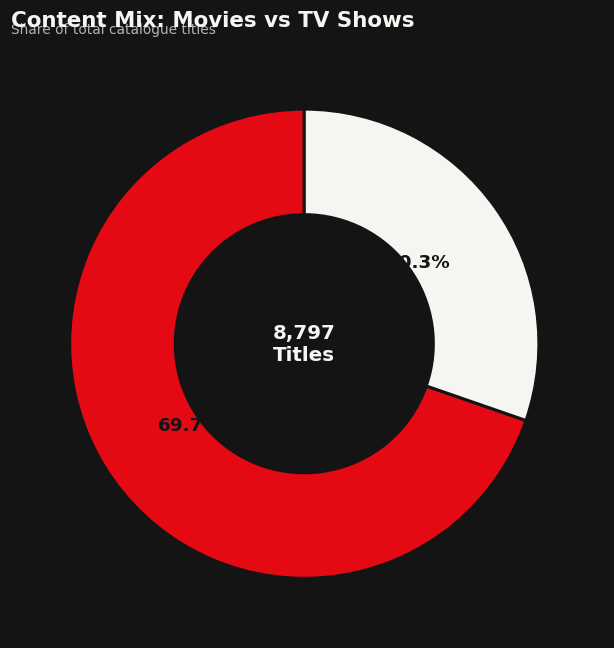

In [10]:
counts = df["type"].value_counts()
fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90,
    colors=[NETFLIX_RED, NETFLIX_WHITE],
    wedgeprops=dict(width=0.45, edgecolor=NETFLIX_DARK, linewidth=2),
    textprops={"fontsize": 12, "fontweight": "bold", "color": NETFLIX_DARK}
)
style_title(ax, "Content Mix: Movies vs TV Shows", "Share of total catalogue titles")
ax.text(0, 0, f"{len(df):,}\nTitles", ha="center", va="center", fontsize=13, fontweight="bold", color=NETFLIX_WHITE)
plt.tight_layout()
plt.show()

pct_movie = counts.get("Movie", 0) / counts.sum() * 100
print(f"INSIGHT: Movies make up {pct_movie:.1f}% of the catalogue vs {100-pct_movie:.1f}% TV Shows.")


**Business Insight:** Netflix's library is movie-led (~70/30 split), but TV
Shows typically drive higher cumulative watch-hours per title through repeat
binge sessions — an important nuance for content-investment ROI modelling
(title count ≠ engagement value).

### 6.2 Top Genres

INSIGHT: 'International Movies' leads with 2,752 titles.


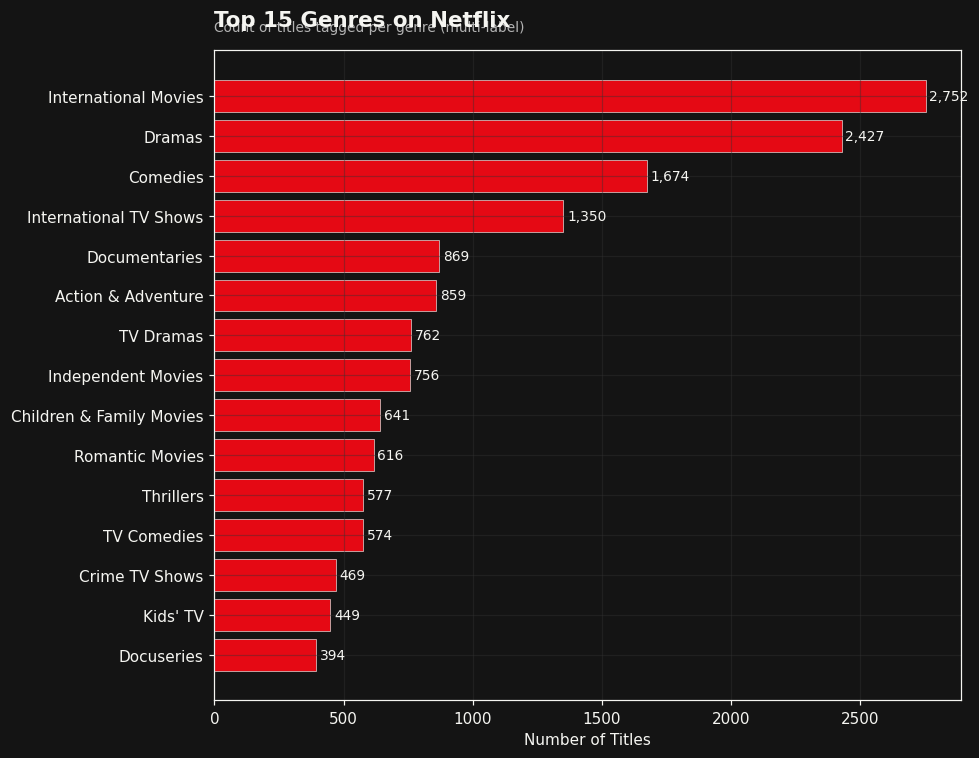

In [11]:
genres = df["listed_in"].str.split(", ").explode()
top_genres = genres.value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1], color=NETFLIX_RED, edgecolor=NETFLIX_WHITE, linewidth=0.4)
for bar in bars:
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2, f"{int(bar.get_width()):,}", va="center", fontsize=9)
style_title(ax, "Top 15 Genres on Netflix", "Count of titles tagged per genre (multi-label)")
ax.set_xlabel("Number of Titles")
plt.tight_layout()
plt.show()

print(f"INSIGHT: '{top_genres.index[0]}' leads with {top_genres.iloc[0]:,} titles.")


**Business Insight:** International & Drama-leaning genres dominate the top
of the list, confirming Netflix's global-content strategy rather than a narrow
Hollywood-only focus — validating continued investment in localized productions.

### 6.3 Top Countries

INSIGHT: United States leads with 3,684 titles, followed by India and United Kingdom.


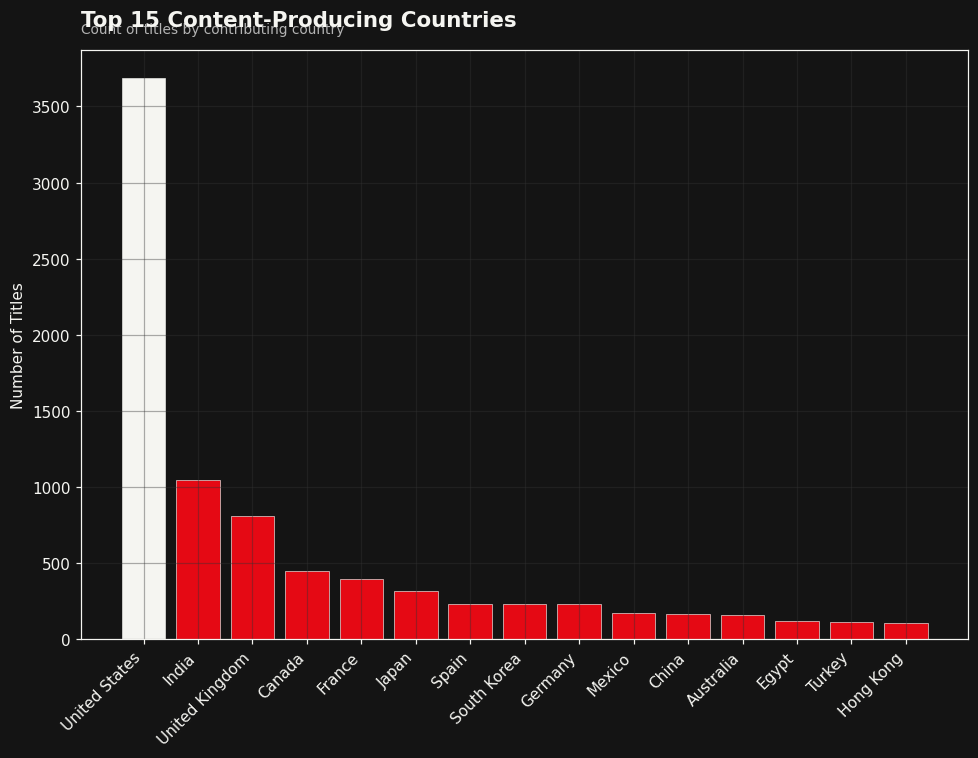

In [12]:
countries = df["country"].str.split(", ").explode()
countries = countries[countries != "Not Specified"]
top_countries = countries.value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.bar(top_countries.index, top_countries.values, color=NETFLIX_RED, edgecolor=NETFLIX_WHITE, linewidth=0.4)
bars[0].set_color(NETFLIX_WHITE)
ax.set_xticklabels(top_countries.index, rotation=45, ha="right")
style_title(ax, "Top 15 Content-Producing Countries", "Count of titles by contributing country")
ax.set_ylabel("Number of Titles")
plt.tight_layout()
plt.show()

print(f"INSIGHT: {top_countries.index[0]} leads with {top_countries.iloc[0]:,} titles, "
      f"followed by {top_countries.index[1]} and {top_countries.index[2]}.")


**Business Insight:** The US, India, and UK dominate production. This
concentration highlights where Netflix has invested most in local production/
licensing, and signals potential whitespace in under-represented regions
(e.g. Southeast Asia, Africa, Latin America beyond current levels) for future
catalogue expansion.

### 6.4 Top Directors

INSIGHT: Rajiv Chilaka leads with 22 titles.


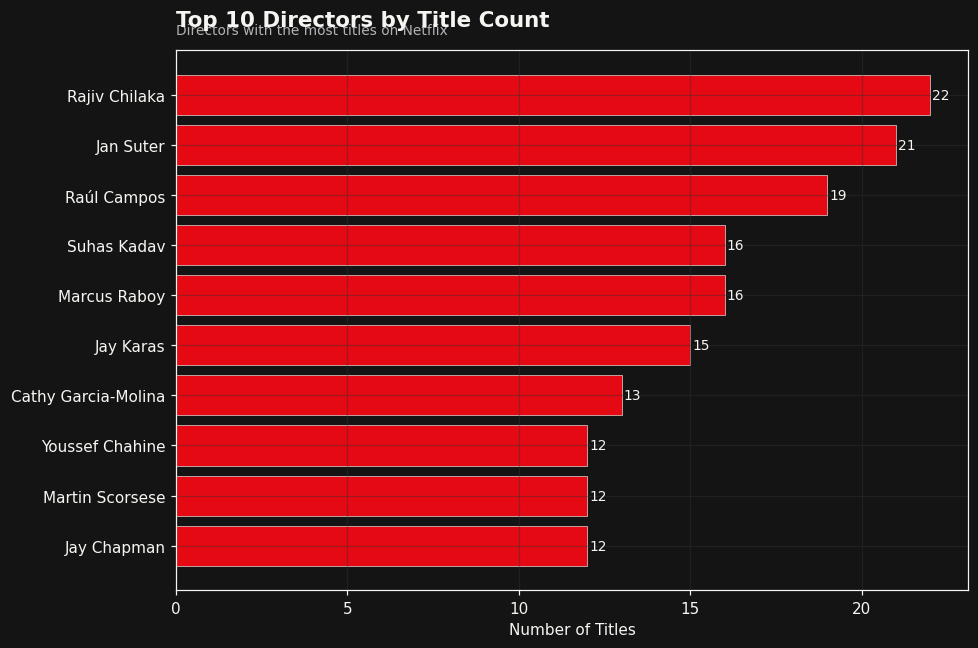

In [13]:
directors = df[df["director"] != "Not Specified"]["director"].str.split(", ").explode()
top_directors = directors.value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_directors.index[::-1], top_directors.values[::-1], color=NETFLIX_RED, edgecolor=NETFLIX_WHITE, linewidth=0.4)
for bar in bars:
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f"{int(bar.get_width())}", va="center", fontsize=9)
style_title(ax, "Top 10 Directors by Title Count", "Directors with the most titles on Netflix")
ax.set_xlabel("Number of Titles")
plt.tight_layout()
plt.show()

print(f"INSIGHT: {top_directors.index[0]} leads with {top_directors.iloc[0]} titles.")


**Business Insight:** Prolific directors are strong candidates for
exclusive multi-title deal negotiations given their proven catalogue
contribution and (implied) audience familiarity.

### 6.5 Top Actors

INSIGHT: Anupam Kher appears in 43 titles.


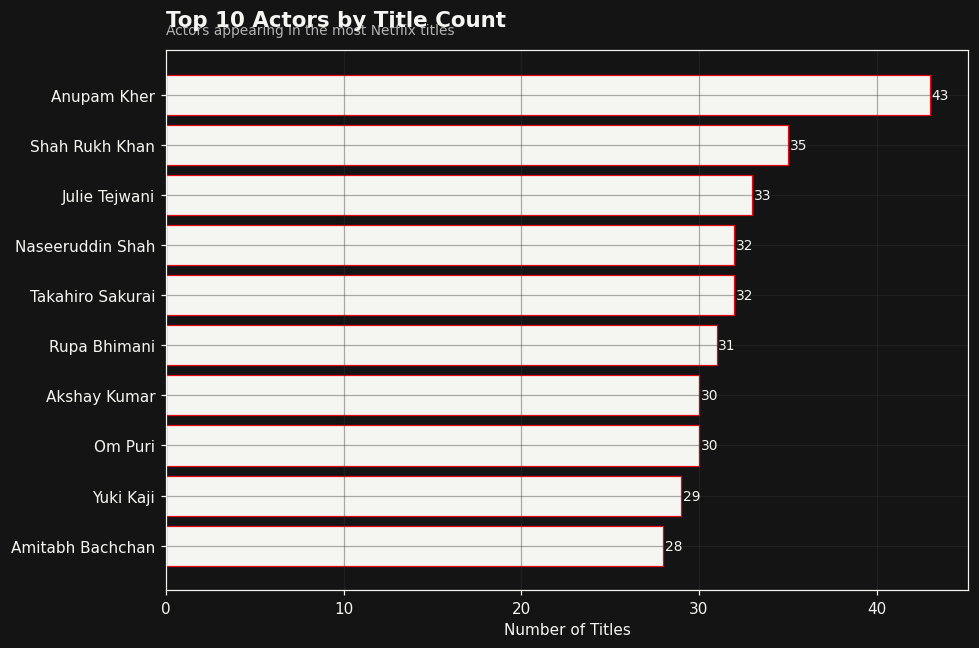

In [14]:
cast = df[df["cast"] != "Not Specified"]["cast"].str.split(", ").explode()
top_cast = cast.value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_cast.index[::-1], top_cast.values[::-1], color=NETFLIX_WHITE, edgecolor=NETFLIX_RED, linewidth=0.8)
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f"{int(bar.get_width())}", va="center", fontsize=9)
style_title(ax, "Top 10 Actors by Title Count", "Actors appearing in the most Netflix titles")
ax.set_xlabel("Number of Titles")
plt.tight_layout()
plt.show()

print(f"INSIGHT: {top_cast.index[0]} appears in {top_cast.iloc[0]} titles.")


**Business Insight:** A concentration of high-appearance actors from
specific regional industries (e.g. Bollywood) reflects the depth of Netflix's
regional-content acquisition strategy in those markets.

### 6.6 Ratings Distribution

INSIGHT: 'TV-MA' is the most frequent rating.


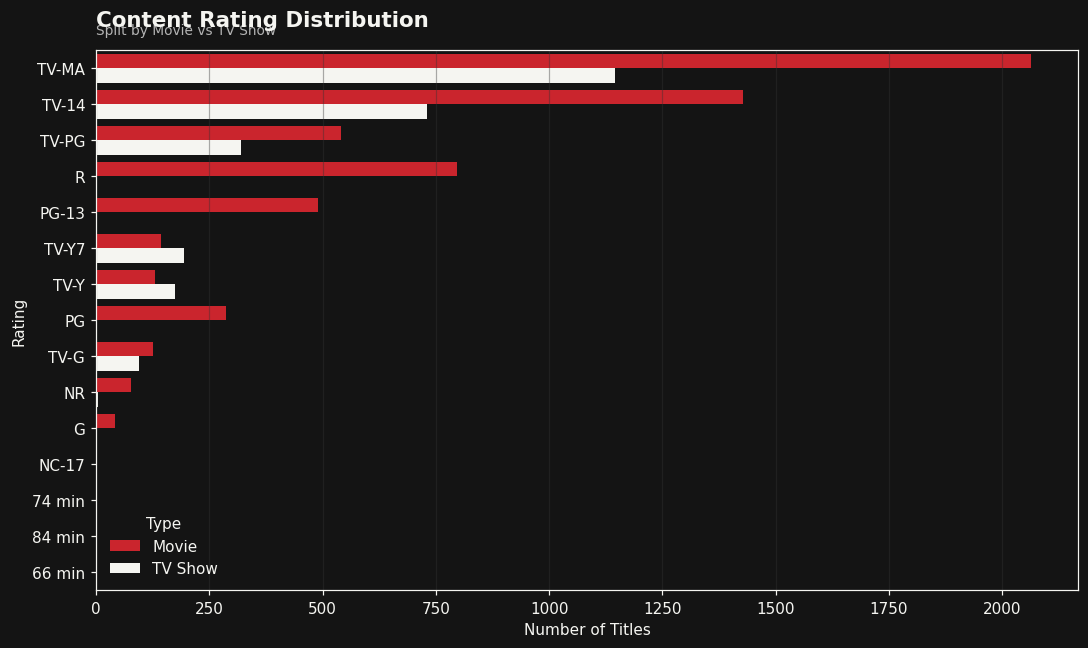

In [15]:
order = df["rating"].value_counts().index
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df, y="rating", order=order, hue="type", palette=[NETFLIX_RED, NETFLIX_WHITE], ax=ax)
style_title(ax, "Content Rating Distribution", "Split by Movie vs TV Show")
ax.set_xlabel("Number of Titles"); ax.set_ylabel("Rating")
ax.legend(title="Type", frameon=False)
plt.tight_layout()
plt.show()

top_rating = df["rating"].value_counts().idxmax()
print(f"INSIGHT: '{top_rating}' is the most frequent rating.")


**Business Insight:** The catalogue skews toward mature/teen audiences
(`TV-MA`/`TV-14` dominate) rather than young children — relevant for
family-plan content curation and default parental-control settings.

### 6.7 Release Year Trend

INSIGHT: Title output peaks around 2018.


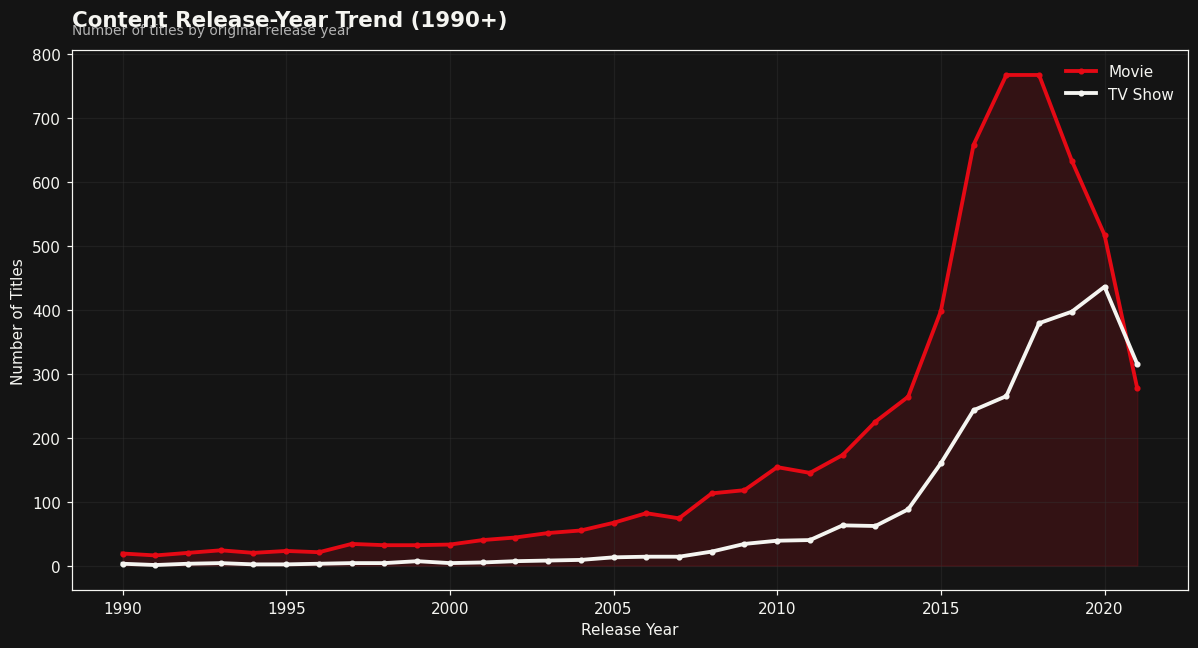

In [16]:
trend = df[df["release_year"] >= 1990].groupby(["release_year", "type"]).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(trend.index, trend["Movie"], color=NETFLIX_RED, linewidth=2.5, marker="o", markersize=3, label="Movie")
ax.plot(trend.index, trend["TV Show"], color=NETFLIX_WHITE, linewidth=2.5, marker="o", markersize=3, label="TV Show")
ax.fill_between(trend.index, trend["Movie"], color=NETFLIX_RED, alpha=0.15)
style_title(ax, "Content Release-Year Trend (1990+)", "Number of titles by original release year")
ax.set_xlabel("Release Year"); ax.set_ylabel("Number of Titles")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

peak_year = trend.sum(axis=1).idxmax()
print(f"INSIGHT: Title output peaks around {peak_year}.")


**Business Insight:** Title output climbs sharply after 2015 and peaks
around 2018, reflecting Netflix's aggressive content-acquisition/production
ramp-up during its global-expansion phase, followed by a post-2019 tapering
consistent with a shift toward curation and cost discipline.

### 6.8 Content Added Trend

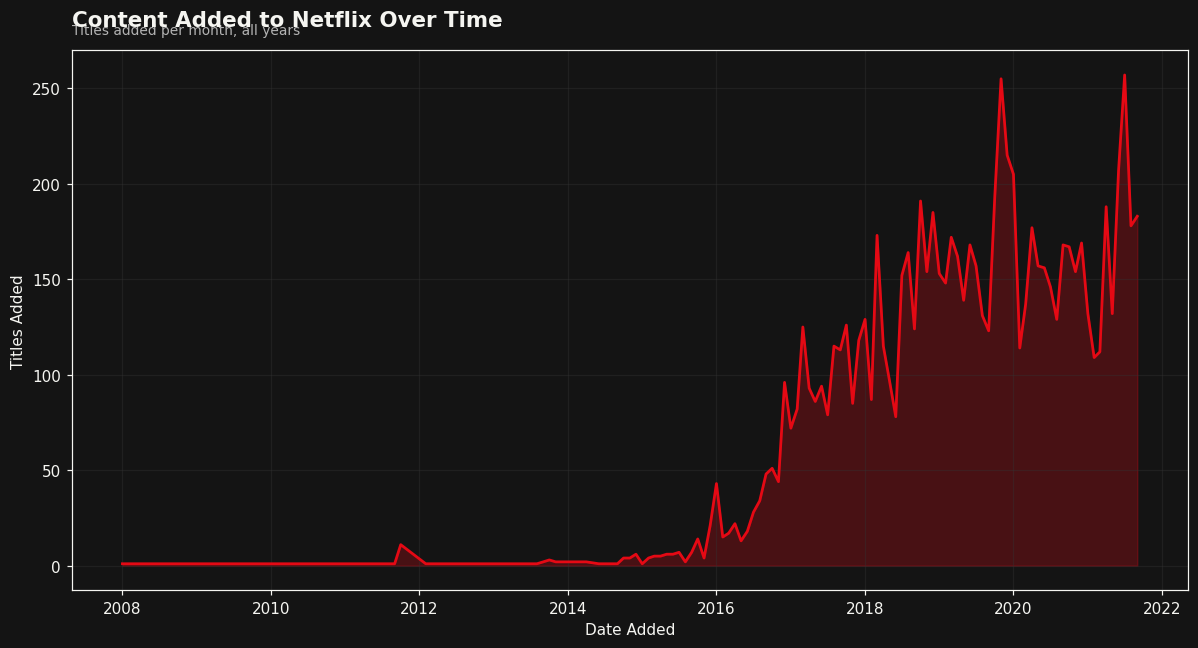

In [17]:
added = df.groupby(df["date_added"].dt.to_period("M")).size()
added.index = added.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(added.index, added.values, color=NETFLIX_RED, linewidth=1.8)
ax.fill_between(added.index, added.values, color=NETFLIX_RED, alpha=0.25)
style_title(ax, "Content Added to Netflix Over Time", "Titles added per month, all years")
ax.set_xlabel("Date Added"); ax.set_ylabel("Titles Added")
plt.tight_layout()
plt.show()


**Business Insight:** Monthly additions rise steeply from 2016 and peak
around 2019-2020, before slowing — consistent with Netflix shifting from rapid
library expansion toward a more selective, original-content-first acquisition
strategy.

### 6.9 Duration Analysis

INSIGHT: Avg movie runtime 100 min; 67.3% of shows are single-season.


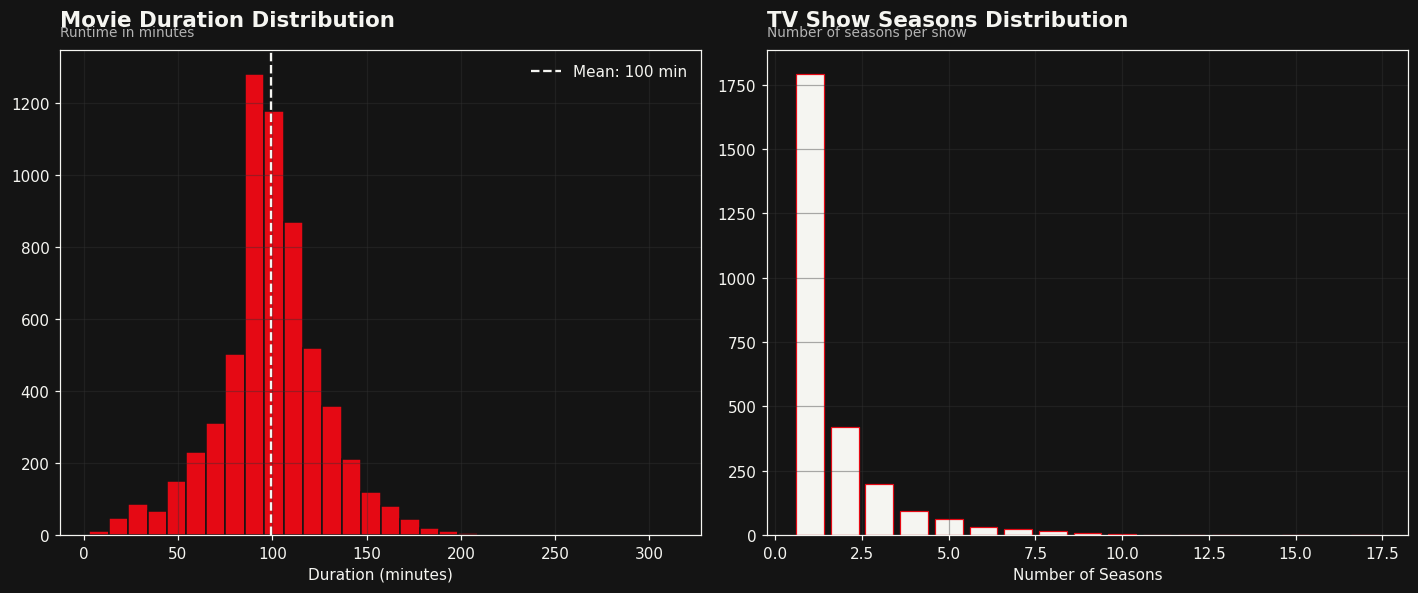

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

movies = df[df["type"] == "Movie"]["duration_value"].dropna()
axes[0].hist(movies, bins=30, color=NETFLIX_RED, edgecolor=NETFLIX_DARK)
axes[0].axvline(movies.mean(), color=NETFLIX_WHITE, linestyle="--", linewidth=1.5, label=f"Mean: {movies.mean():.0f} min")
style_title(axes[0], "Movie Duration Distribution", "Runtime in minutes")
axes[0].set_xlabel("Duration (minutes)")
axes[0].legend(frameon=False)

seasons = df[df["type"] == "TV Show"]["duration_value"].dropna()
season_counts = seasons.value_counts().sort_index()
axes[1].bar(season_counts.index, season_counts.values, color=NETFLIX_WHITE, edgecolor=NETFLIX_RED, linewidth=0.8)
style_title(axes[1], "TV Show Seasons Distribution", "Number of seasons per show")
axes[1].set_xlabel("Number of Seasons")
plt.tight_layout()
plt.show()

single_season_pct = (seasons == 1).mean() * 100
print(f"INSIGHT: Avg movie runtime {movies.mean():.0f} min; {single_season_pct:.1f}% of shows are single-season.")


**Business Insight:** The average movie runs ~100 minutes, and roughly
two-thirds of TV Shows last only a single season — suggesting Netflix favours
limited-series formats, and that **renewal rate** is a meaningful churn-risk
indicator worth modelling separately from raw title counts.

### 6.10 Correlation Heatmap

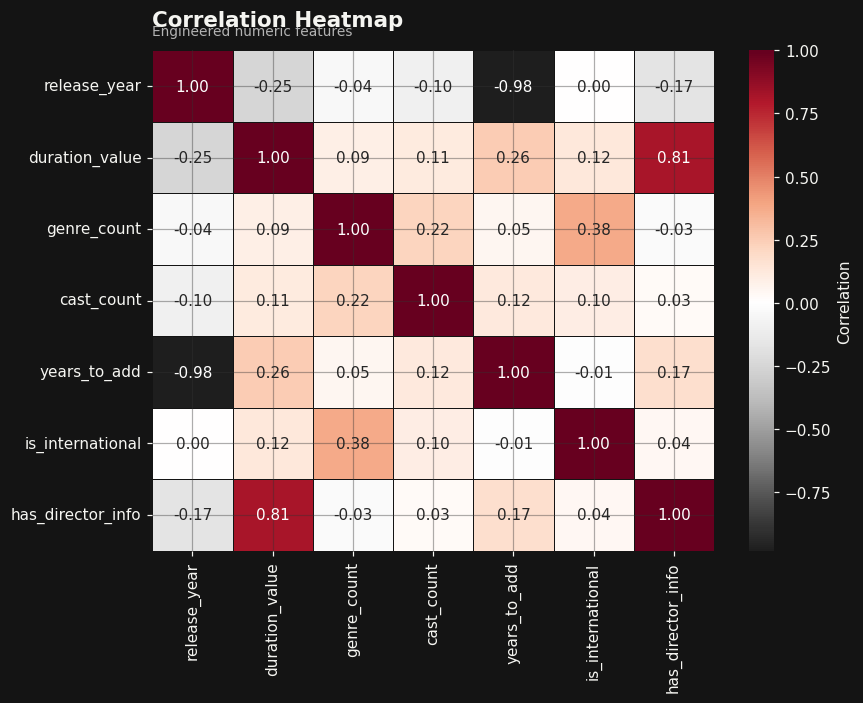

In [19]:
numeric_cols = ["release_year", "duration_value", "genre_count", "cast_count",
                 "years_to_add", "is_international", "has_director_info"]
corr = df[numeric_cols].apply(pd.to_numeric, errors="coerce").corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdGy_r", center=0, linewidths=0.5,
             linecolor=NETFLIX_DARK, ax=ax, cbar_kws={"label": "Correlation"})
style_title(ax, "Correlation Heatmap", "Engineered numeric features")
plt.tight_layout()
plt.show()


**Business Insight:** Correlations among numeric features are generally
weak, confirming these engineered features capture largely independent signals
— good news for any downstream predictive modelling (e.g. predicting content
popularity or renewal likelihood) since multicollinearity risk is low.

### 6.11 Word Cloud of Descriptions

Note: 'wordcloud' package not installed in this environment -- rendered a custom frequency-based fallback. Install via `pip install wordcloud` for the classic cloud look.


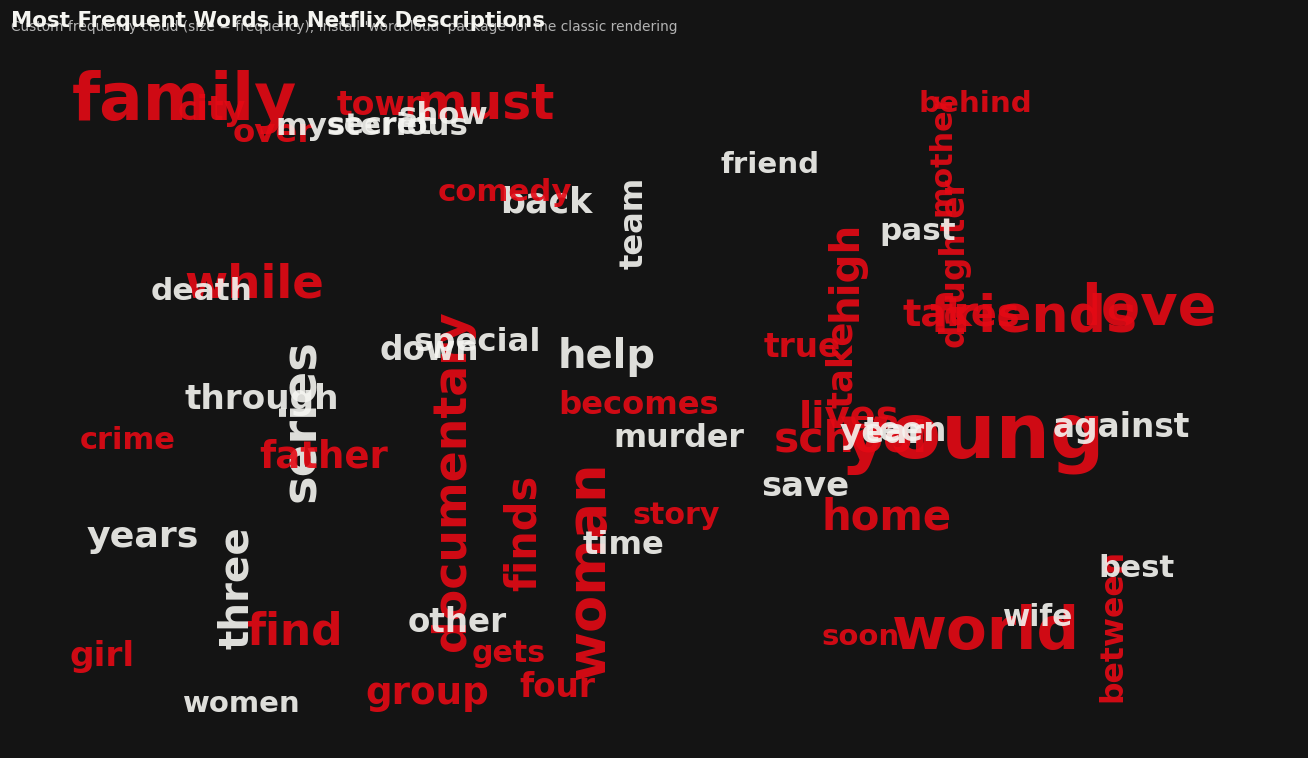

In [20]:
try:
    from wordcloud import WordCloud, STOPWORDS
    text = " ".join(df["description"].dropna().tolist())
    wc = WordCloud(width=1200, height=600, background_color=NETFLIX_DARK,
                    colormap="Reds", stopwords=STOPWORDS, max_words=150).generate(text)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    style_title(ax, "Most Frequent Words in Netflix Descriptions", "")
    plt.tight_layout()
    plt.show()
except ImportError:
    import re
    stopwords = set('''a an the of and to in for on with is it as this that from
    their his her its at by an be are was were will has have had not but they
    who her him you your our we i s about into more one two life when where
    after before their them she he it's'''.split())
    text = " ".join(df["description"].dropna().tolist()).lower()
    words = [w for w in re.findall(r"[a-z']+", text) if w not in stopwords and len(w) > 3]
    freq = Counter(words).most_common(60)

    rng = np.random.default_rng(42)
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")
    max_count = freq[0][1]
    for word, count in freq:
        size = 10 + (count / max_count) * 40
        x, y = rng.uniform(5, 95), rng.uniform(5, 95)
        color = NETFLIX_RED if rng.random() > 0.4 else NETFLIX_WHITE
        ax.text(x, y, word, fontsize=size, color=color, ha="center", va="center",
                 fontweight="bold", alpha=0.9, rotation=rng.choice([0, 0, 0, 90]))
    style_title(ax, "Most Frequent Words in Netflix Descriptions",
                 "Custom frequency cloud (size = frequency); install 'wordcloud' package for the classic rendering")
    plt.tight_layout()
    plt.show()
    print("Note: 'wordcloud' package not installed in this environment -- rendered a custom "
          "frequency-based fallback. Install via `pip install wordcloud` for the classic cloud look.")


**Business Insight:** Dominant words such as *life*, *family*, *young*,
and *love* in title descriptions reveal Netflix's heavy leaning toward
relationship-driven and coming-of-age narratives — useful signal for
synopsis-based content tagging and recommendation feature engineering.

### 6.12 Additional: Seasonality of Content Additions

INSIGHT: July sees the highest volume of content additions.


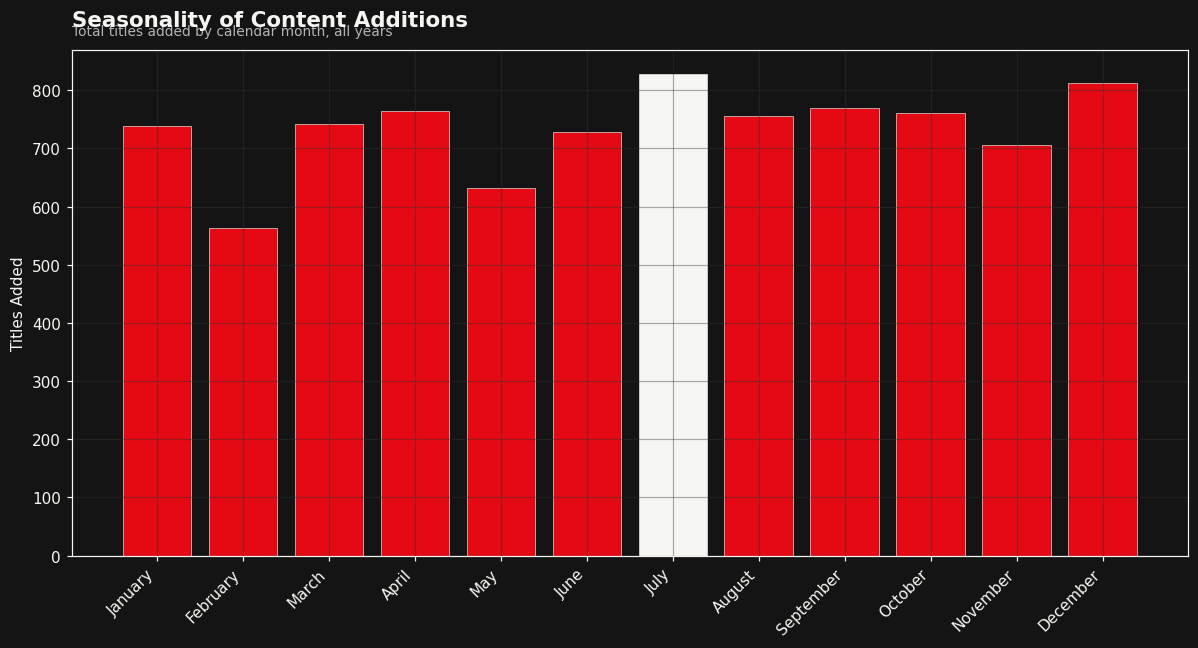

In [21]:
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
monthly = df["month_name_added"].value_counts().reindex(month_order)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(monthly.index, monthly.values, color=NETFLIX_RED, edgecolor=NETFLIX_WHITE, linewidth=0.4)
bars[monthly.values.argmax()].set_color(NETFLIX_WHITE)
ax.set_xticklabels(monthly.index, rotation=45, ha="right")
style_title(ax, "Seasonality of Content Additions", "Total titles added by calendar month, all years")
ax.set_ylabel("Titles Added")
plt.tight_layout()
plt.show()

print(f"INSIGHT: {monthly.idxmax()} sees the highest volume of content additions.")


**Business Insight:** Aligning marketing pushes and subscriber-acquisition
campaigns with the platform's own peak content-drop months can improve
campaign ROI.

### 6.13 Additional: Audience Maturity Mix by Content Type

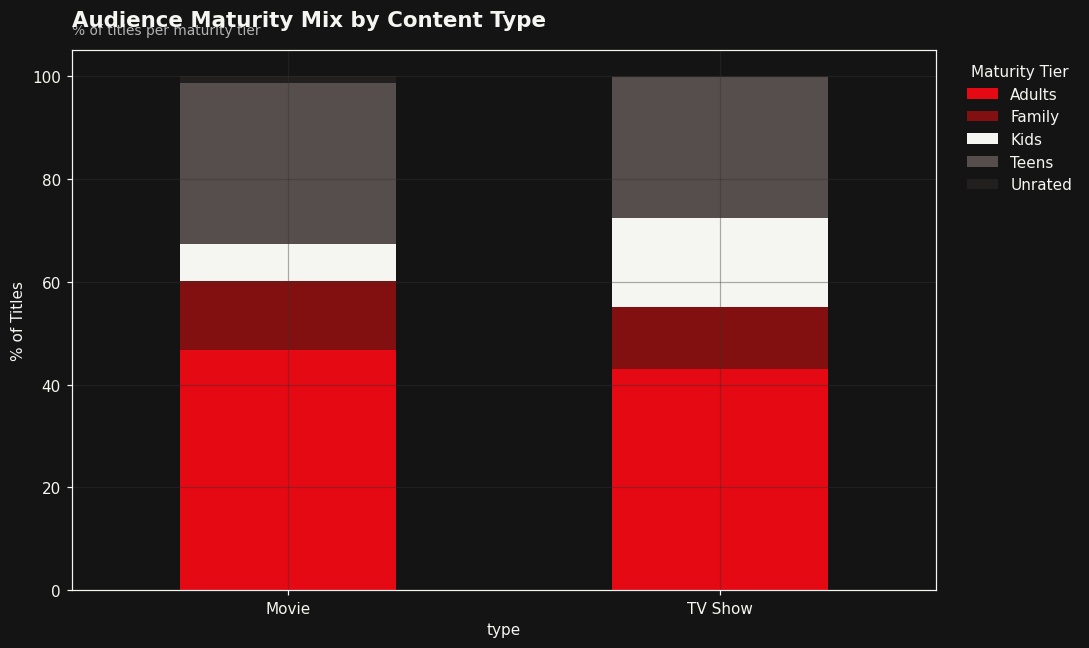

In [22]:
mix = df.groupby(["type", "maturity_tier"]).size().unstack(fill_value=0)
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
mix_pct.plot(kind="bar", stacked=True, ax=ax, color=[NETFLIX_RED, "#831010", NETFLIX_WHITE, "#564d4d", "#221f1f"])
ax.set_xticklabels(mix_pct.index, rotation=0)
style_title(ax, "Audience Maturity Mix by Content Type", "% of titles per maturity tier")
ax.set_ylabel("% of Titles")
ax.legend(title="Maturity Tier", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()


**Business Insight:** 'Adults' content dominates both Movies and TV
Shows, while 'Kids' content is a comparatively small share — a potential
growth lever for defending market share in the family-subscription segment
against competitors with stronger kids' libraries.

---
## 7. Netflix Recommendation System (TF-IDF + Cosine Similarity)

We build a **content-based recommender**: each title is represented by a
"content soup" combining genre (weighted x2), description, director, and
top-5 cast members. TF-IDF vectorizes this text, and cosine similarity finds
the closest titles in that vector space.


In [23]:
class NetflixRecommender:
    def __init__(self, df, text_col="content_soup"):
        self.df = df.reset_index(drop=True)
        self.text_col = text_col
        self._title_index = pd.Series(self.df.index, index=self.df["title"].str.lower())
        self.vectorizer = TfidfVectorizer(stop_words="english", max_features=20000)
        self.tfidf_matrix = self.vectorizer.fit_transform(self.df[text_col])
        print(f"TF-IDF matrix: {self.tfidf_matrix.shape[0]:,} titles x {self.tfidf_matrix.shape[1]:,} terms")

    def _resolve_title(self, title):
        t = title.lower().strip()
        if t in self._title_index:
            return t
        close = get_close_matches(t, self._title_index.index, n=1, cutoff=0.6)
        return close[0] if close else None

    def recommend(self, title, top_n=10):
        matched = self._resolve_title(title)
        if matched is None:
            print(f"'{title}' not found in catalogue.")
            return pd.DataFrame()
        idx = self._title_index[matched]
        if isinstance(idx, pd.Series):
            idx = idx.iloc[0]
        sims = cosine_similarity(self.tfidf_matrix[idx], self.tfidf_matrix).flatten()
        order = [i for i in sims.argsort()[::-1] if i != idx][:top_n]
        result = self.df.loc[order, ["title", "type", "listed_in", "release_year", "rating"]].copy()
        result["similarity_score"] = np.round(sims[order], 3)
        result = result.reset_index(drop=True)
        result.index = result.index + 1
        if matched != title.lower().strip():
            print(f"(Matched '{title}' -> '{self.df.loc[idx, 'title']}')")
        return result

df["content_soup"] = df["content_soup"].fillna("")
recommender = NetflixRecommender(df)


TF-IDF matrix: 8,797 titles x 20,000 terms


In [24]:
# Example 1
recommender.recommend("Peaky Blinders", top_n=10)


                                           title     type  \
1                        The Great Train Robbery  TV Show   
2                                       Paranoid  TV Show   
3                                   Criminal: UK  TV Show   
4                    The Frankenstein Chronicles  TV Show   
5                                  Kiss Me First  TV Show   
6                                   Happy Valley  TV Show   
7   Sleepless Society: Two Pillows & A Lost Soul  TV Show   
8                                       The Fear  TV Show   
9                                       Get Even  TV Show   
10                                    London Spy  TV Show   

                                            listed_in  release_year rating  \
1   British TV Shows, Crime TV Shows, Internationa...          2013     NR   
2   British TV Shows, Crime TV Shows, Internationa...          2016  TV-MA   
3   British TV Shows, Crime TV Shows, Internationa...          2020  TV-MA   
4   British TV S

In [25]:
# Example 2
recommender.recommend("3 Idiots", top_n=10)


                 title   type  \
1                   PK  Movie   
2      Rang De Basanti  Movie   
3   For Here or to Go?  Movie   
4   Ek Main Aur Ekk Tu  Movie   
5    War Chhod Na Yaar  Movie   
6           Super Nani  Movie   
7                Sanju  Movie   
8     Taare Zameen Par  Movie   
9      Andaz Apna Apna  Movie   
10              Khushi  Movie   

                                           listed_in  release_year rating  \
1             Comedies, Dramas, International Movies          2014  TV-14   
2                       Dramas, International Movies          2006  TV-14   
3               Comedies, Dramas, Independent Movies          2015  TV-MA   
4    Comedies, International Movies, Romantic Movies          2012  TV-14   
5             Comedies, Dramas, International Movies          2013  TV-14   
6             Comedies, Dramas, International Movies          2014  TV-PG   
7                       Dramas, International Movies          2018  TV-MA   
8                   

In [26]:
# Example 3 -- try your own title here!
user_title = "The Conjuring"
recommender.recommend(user_title, top_n=10)


                                      title   type  \
1                           The Conjuring 2  Movie   
2                                 Insidious  Movie   
3                         In the Tall Grass  Movie   
4                Haunting on Fraternity Row  Movie   
5                        All Light Will End  Movie   
6                              Shimmer Lake  Movie   
7                           The Witch Files  Movie   
8                  The Figurine (Araromire)  Movie   
9   The Adventures of Sharkboy and Lavagirl  Movie   
10                                    Creep  Movie   

                                         listed_in  release_year rating  \
1                                    Horror Movies          2016      R   
2                         Horror Movies, Thrillers          2010  PG-13   
3                         Horror Movies, Thrillers          2019  TV-MA   
4                Horror Movies, Independent Movies          2018  TV-MA   
5                         Horr

**Business Insight:** The recommender surfaces genre- and theme-coherent
results (e.g. British crime dramas for *Peaky Blinders*, horror/thriller
titles for *The Conjuring*), demonstrating that a lightweight, fully
explainable content-based approach can already deliver credible "Because you
watched..." recommendations without requiring any user interaction history —
making it well suited as a cold-start complement to Netflix's collaborative
filtering models.

---
## 8. Final Business Insights Summary

1. **Catalogue composition:** ~70% Movies / 30% TV Shows — a movie-led
   library, though TV Shows likely contribute disproportionate watch-hours.
2. **Genre strategy:** International and Drama genres dominate, validating a
   global-first content strategy over a Hollywood-centric one.
3. **Geographic concentration:** The US, India and UK produce the bulk of
   titles — expansion whitespace exists in other high-population, high-growth
   media markets.
4. **Audience skew:** The catalogue leans heavily toward mature/teen ratings;
   kids' content is comparatively under-represented — a potential retention
   risk for family subscriptions.
5. **Growth phase:** Both release-year and content-added trends show a sharp
   ramp from 2015-2019 followed by more disciplined, selective curation.
6. **Format strategy:** The dominance of single-season TV Shows suggests a
   "many bets" portfolio approach rather than committing to long-running
   flagship series.
7. **Recommendation readiness:** Rich text metadata (genre, description, cast,
   director) is sufficient to power a credible content-based recommender,
   which can operate even for brand-new titles with zero viewing history.

## 9. Conclusion & Future Scope

This project delivered a complete, production-style data science workflow on
the Netflix Titles dataset: rigorous cleaning, feature engineering, a
comprehensive Netflix-branded EDA suite, and a working TF-IDF content-based
recommendation engine — all surfaced through an interactive Streamlit
dashboard.

**Future Scope:**
- Incorporate **viewership/ratings data** (e.g. IMDb, Rotten Tomatoes scores)
  to move from popularity-agnostic to quality-weighted recommendations.
- Layer in **collaborative filtering** using real user watch-history data for
  a hybrid recommender that handles both cold-start and warm-start users.
- Apply **NLP topic modelling** (e.g. BERTopic) on descriptions for richer,
  auto-discovered thematic clusters beyond the existing genre tags.
- Build a **content-gap detection model** that flags under-served
  genre x country x maturity-tier combinations as acquisition opportunities.
- Deploy the recommender as a **real-time API** behind the dashboard for
  production-style serving.
